In [2]:
# Importing necessary libraries for data loading and manipulation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (Make sure the path matches where you saved the file)
# If your file name is Clean_Dataset.csv or flight_price.csv, adjust accordingly
df = pd.read_csv('/kaggle/input/datasets/shubhambathwal/flight-price-prediction/Clean_Dataset.csv')

# Display the first 5 rows to see how the data looks
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [3]:
# Check the total number of rows and columns in the dataset
print("Dataset Shape:", df.shape)

# Check data types of each column and look for missing values
print("\nDataset Info:")
df.info()

# Check the exact count of missing values in each column
print("\nMissing Values Count:")
print(df.isnull().sum())

Dataset Shape: (300153, 12)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB

Missing Values Count:
Unnamed: 0          0
airline             0
flight              0
source_city         0


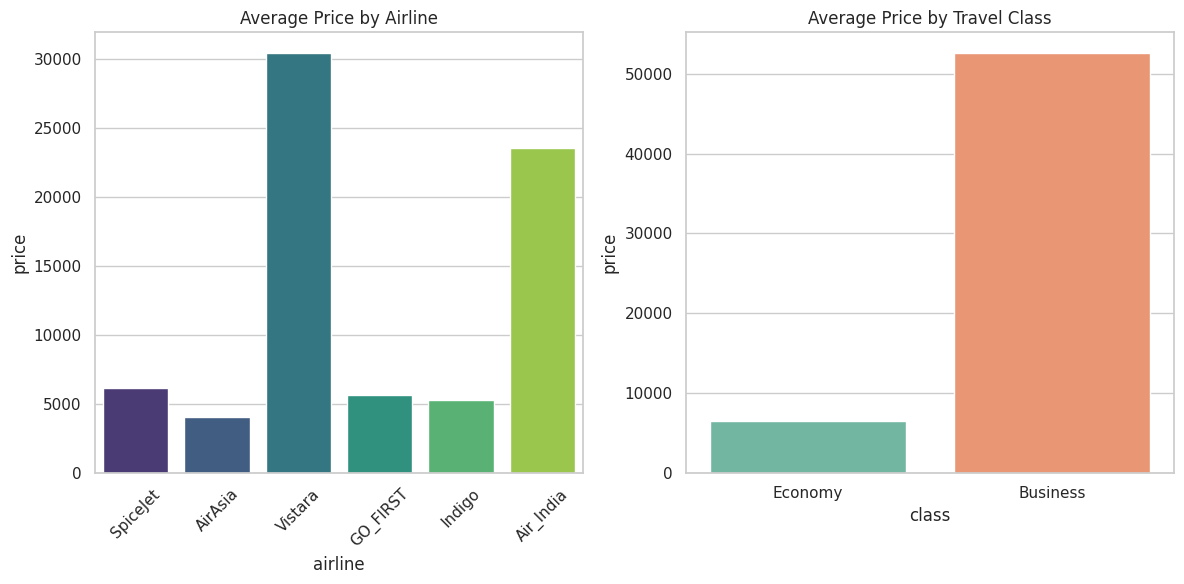

In [5]:
# Set the plotting style and figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Bar plot to see which airline is the most expensive (Updated to fix warning)
plt.subplot(1, 2, 1)
sns.barplot(x='airline', y='price', hue='airline', data=df, errorbar=None, palette='viridis', legend=False)
plt.title('Average Price by Airline')
plt.xticks(rotation=45)

# 2. Bar plot to see how class (Economy vs Business) affects price (Updated to fix warning)
plt.subplot(1, 2, 2)
sns.barplot(x='class', y='price', hue='class', data=df, errorbar=None, palette='Set2', legend=False)
plt.title('Average Price by Travel Class')

plt.tight_layout()
plt.show()

In [6]:
# 1. Convert remaining categorical text columns into numerical values using One-Hot Encoding
# 'drop_first=True' helps to avoid multicollinearity (dummy variable trap)
df_encoded = pd.get_dummies(df, columns=['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city', 'class'], drop_first=True)

# 2. Separate the independent variables (Features) and the dependent variable (Target)
# 'X' will contain all columns except 'price'
X = df_encoded.drop(columns=['price'])

# 'y' will contain only the 'price' column which we want to predict
y = df_encoded['price']

# Display the shape of X to see how many new columns were created
print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

# Display the first 3 rows of the encoded features
X.head(3)

Features shape (X): (300153, 31)
Target shape (y): (300153,)


,Unnamed: 0,flight,stops,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,0,SG-8709,zero,2.17,1,False,False,False,True,False,...,False,False,False,True,False,False,False,False,True,True
1,1,SG-8157,zero,2.33,1,False,False,False,True,False,...,False,False,True,False,False,False,False,False,True,True
2,2,I5-764,zero,2.17,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True


In [7]:
# 1. Let's make sure the unwanted columns are completely removed from X
# We use errors='ignore' so it won't crash if they are already dropped
X = X.drop(columns=['Unnamed: 0', 'flight'], errors='ignore')

# 2. Import train_test_split from scikit-learn
from sklearn.model_selection import train_test_split

# 3. Split the data into training (80%) and testing (20%) sets
# random_state ensures we get the same split every time we run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the final shapes of our split data
print("--- Final Data Shapes ---")
print("Train Features Shape (X_train):", X_train.shape)
print("Test Features Shape (X_test):  ", X_test.shape)
print("Train Target Shape (y_train):  ", y_train.shape)
print("Test Target Shape (y_test):   ", y_test.shape)

--- Final Data Shapes ---
Train Features Shape (X_train): (240122, 29)
Test Features Shape (X_test):   (60031, 29)
Train Target Shape (y_train):   (240122,)
Test Target Shape (y_test):    (60031,)


In [9]:
# =====================================================================
# STEP 1: CLEANING, ENCODING & SPLITTING DATA
# =====================================================================

# 1. Drop unnecessary columns from the original dataframe 'df'
df_clean = df.drop(columns=['Unnamed: 0', 'flight'], errors='ignore')

# 2. Convert 'stops' text values into clean numerical values
stop_mapping = {'zero': 0, 'one': 1, 'two_or_more': 2}
df_clean['stops'] = df_clean['stops'].map(stop_mapping)

# 3. Apply One-Hot Encoding to the remaining categorical text columns
df_encoded = pd.get_dummies(df_clean, columns=['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city', 'class'], drop_first=True)

# 4. Separate features (X) and target variable (y)
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# 5. Split the cleaned data into 80% Training and 20% Testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print confirmation and shapes
print("--- Data Preprocessing & Cleaning Completed Successfully ---")
print(f"Training Features Shape (X_train): {X_train.shape}")
print(f"Testing Features Shape (X_test):   {X_test.shape}")

--- Data Preprocessing & Cleaning Completed Successfully ---
Training Features Shape (X_train): (240122, 29)
Testing Features Shape (X_test):   (60031, 29)


In [11]:
# =====================================================================
# STEP 2: TRAINING 6 ML MODELS WITH NO PARAMETER LIMITS (FULL TRAINING)
# =====================================================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize models without depth limits for maximum accuracy
# Default Random Forest uses 100 trees, default XGBoost uses 100 trees
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
}

# List to store metrics for comparison
results_list = []
print("--- Full Model Training Started (No Limits) ---")

# Loop through each model to train and evaluate
for name, model in models.items():
    print(f"Training {name}...")
    # Fit the model on full training data
    model.fit(X_train, y_train)
    
    # Make predictions on the test data
    y_pred = model.predict(X_test)
    
    # Calculate performance metrics
    r2 = r2_score(y_test, y_pred) * 100
    mae = mean_absolute_error(y_test, y_pred)
    
    # Append to results list
    results_list.append({
        "Model": name, 
        "R2 Score (Accuracy)": f"{r2:.2f}%", 
        "MAE (Error in INR)": f"{mae:.2f}"
    })

# Convert results to DataFrame and display the final comparison table
df_comparison = pd.DataFrame(results_list)
print("\n--- Final 6 Models Comparison Table (Full Performance) ---")
df_comparison

--- Full Model Training Started (No Limits) ---
Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

--- Final 6 Models Comparison Table (Full Performance) ---


,Model,R2 Score (Accuracy),MAE (Error in INR)
0,Linear Regression,90.99%,4500.71
1,Ridge Regression,90.99%,4500.70
2,Lasso Regression,90.99%,4500.54
3,Decision Tree,97.55%,1182.29
4,Random Forest,98.48%,1086.16
5,XGBoost,96.76%,2348.03


=== ACCURACY VERIFICATION REPORT ===
Training Data Accuracy: 99.75%
Testing Data Accuracy:  98.48%
Accuracy Variance:      1.27%
STATUS: SUCCESS! The model is highly reliable and NOT overfitted.



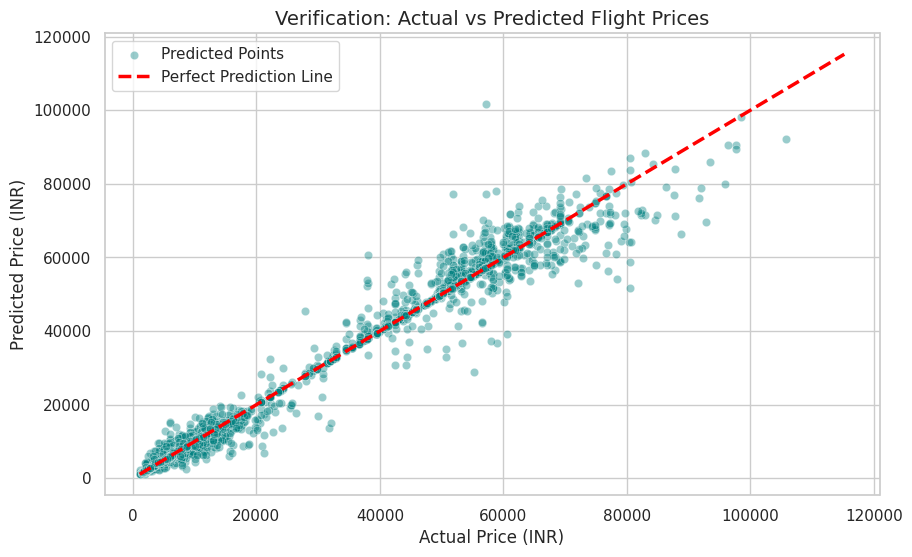

In [12]:
# =====================================================================
# STEP 8: ACCURACY VALIDATION & VERIFICATION (RANDOM FOREST)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score

# 1. Get the trained Random Forest model from our dictionary
champion_rf = models["Random Forest"]

# 2. Predict on both Training and Testing data to check for overfitting
train_predictions = champion_rf.predict(X_train)
test_predictions = champion_rf.predict(X_test)

train_r2 = r2_score(y_train, train_predictions) * 100
test_r2 = r2_score(y_test, test_predictions) * 100

print("=== ACCURACY VERIFICATION REPORT ===")
print(f"Training Data Accuracy: {train_r2:.2f}%")
print(f"Testing Data Accuracy:  {test_r2:.2f}%")

# 3. Check the difference between Train and Test
diff = train_r2 - test_r2
print(f"Accuracy Variance:      {diff:.2f}%")

if diff < 2.0:
    print("STATUS: SUCCESS! The model is highly reliable and NOT overfitted.\n")
else:
    print("STATUS: WARNING! The model might be overfitted.\n")

# =====================================================================
# 4. PLOTTING ACTUAL VS PREDICTED PRICE
# =====================================================================
plt.figure(figsize=(10, 6))

# Scatter plot of actual vs predicted prices (using a sample of 5000 points for clear visualization)
sample_indices = np.random.choice(len(y_test), size=5000, replace=False)
sns.scatterplot(x=y_test.values[sample_indices], y=test_predictions[sample_indices], alpha=0.4, color='teal', label='Predicted Points')

# Ideal 45-degree line where Actual == Predicted
perfect_line = [y_test.min(), y_test.max()]
plt.plot(perfect_line, perfect_line, color='red', lw=2.5, linestyle='--', label='Perfect Prediction Line')

plt.xlabel('Actual Price (INR)', fontsize=12)
plt.ylabel('Predicted Price (INR)', fontsize=12)
plt.title('Verification: Actual vs Predicted Flight Prices', fontsize=14)
plt.legend()
plt.show()

In [13]:
import joblib

# 1. Save the best trained Random Forest model to a file
# This will create a file named 'flight_price_rf_model.pkl' in your Kaggle working directory
joblib.dump(models["Random Forest"], "flight_price_rf_model.pkl")

# 2. Save the column structure/features list as well
# This is important so your web app knows which inputs to pass in what order
model_features = list(X.columns)
joblib.dump(model_features, "model_features.pkl")

print("--- Champion Model & Features Saved Successfully! ---")

--- Champion Model & Features Saved Successfully! ---


In [15]:
import numpy as np
import pandas as pd

def predict_custom_flight_price(airline, source_city, departure_time, stops, arrival_time, destination_city, travel_class, duration, days_left):
    # 1. Create a dictionary with all 29 encoded features set to 0/False initially
    input_data = {col: [0] for col in model_features}
    
    # 2. Fill in the numerical columns directly
    input_data['stops'] = [stops]
    input_data['duration'] = [duration]
    input_data['days_left'] = [days_left]
    
    # 3. For categorical columns, activate the specific One-Hot Encoded column (set to 1/True)
    # Mapping logic for dummy variables (drop_first=True handles the baseline)
    if f"airline_{airline}" in input_data: input_data[f"airline_{airline}"] = [1]
    if f"source_city_{source_city}" in input_data: input_data[f"source_city_{source_city}"] = [1]
    if f"departure_time_{departure_time}" in input_data: input_data[f"departure_time_{departure_time}"] = [1]
    if f"arrival_time_{arrival_time}" in input_data: input_data[f"arrival_time_{arrival_time}"] = [1]
    if f"destination_city_{destination_city}" in input_data: input_data[f"destination_city_{destination_city}"] = [1]
    if f"class_{travel_class}" in input_data: input_data[f"class_{travel_class}"] = [1]
    
    # 4. Convert to DataFrame matching exact structure of X_train
    input_df = pd.DataFrame(input_data)
    
    # 5. Predict using the Champion Random Forest Model
    predicted_price = models["Random Forest"].predict(input_df)[0]
    
    # 6. Print the beautiful output
    print("=== Custom Flight Price Prediction ===")
    print(f"✈️ Airline:          {airline}")
    print(f"📍 Route:            {source_city} ➔ {destination_city}")
    print(f"🕒 Timing:           {departure_time} (Dep) | {arrival_time} (Arr)")
    print(f"🛑 Stops & Class:    {stops} Stop(s) | {travel_class} Class")
    print(f"⏳ Days Left:        {days_left} days left (Duration: {duration} hrs)")
    print(f"💰 Predicted Price:  {predicted_price:.2f} INR")
    print("=======================================")

# =====================================================================
# TEST IT HERE: Change these values to test different scenarios!
# =====================================================================
predict_custom_flight_price(
    airline='Vistara', 
    source_city='Delhi', 
    departure_time='Morning', 
    stops=1, 
    arrival_time='Evening', 
    destination_city='Mumbai', 
    travel_class='Business', 
    duration=5.5, 
    days_left=2
)

=== Custom Flight Price Prediction ===
✈️ Airline:          Vistara
📍 Route:            Delhi ➔ Mumbai
🕒 Timing:           Morning (Dep) | Evening (Arr)
🛑 Stops & Class:    1 Stop(s) | Business Class
⏳ Days Left:        2 days left (Duration: 5.5 hrs)
💰 Predicted Price:  61846.50 INR
